In [48]:
#Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

import warnings
warnings.filterwarnings("ignore")

In [49]:
#upload dataset
from google.colab import files

uploaded = files.upload()

Saving indian-crimes-from-jan-to-aug-2025.csv to indian-crimes-from-jan-to-aug-2025 (2).csv


In [50]:
#Load the CSV

file_name = "indian-crimes-from-jan-to-aug-2025.csv"
df = pd.read_csv("/content/indian-crimes-from-jan-to-aug-2025 (1).csv")

In [51]:
# Display the dataset
df.head()


,Law under which they are registered,Crime + Legal Section,Reason,Number of cases from Jan to Aug(2025),Number of cases in Aug of last year(2024),Number of cases in July(2025),Number of cases in Aug(2025)
0,A - IPC Crime,"Murder (Sec.302/303 IPC/103,104 BNS)",For gain,24.0,4.0,3.0,3.0
1,A - IPC Crime,"Murder (Sec.302/303 IPC/103,104 BNS)",Over Property Dispute,17.0,1.0,2.0,1.0
2,A - IPC Crime,"Murder (Sec.302/303 IPC/103,104 BNS)",Due to Personal Vendetta or enemity,26.0,2.0,3.0,3.0
3,A - IPC Crime,"Murder (Sec.302/303 IPC/103,104 BNS)",Due to Sexual jealousy,16.0,1.0,1.0,2.0
4,A - IPC Crime,"Murder (Sec.302/303 IPC/103,104 BNS)",For dowry by burning,1.0,0.0,0.0,0.0


In [52]:
#Finding the size of the dataset

rows, columns = df.shape

print("Number of rows: ", rows)
print("Number of columns: ", columns)

Number of rows:  689
Number of columns:  7


In [53]:
#Column names
print("Columns in the dataset:\n")
for column in df.columns:
  print(column)

Columns in the dataset:

Law under which they are registered
Crime + Legal Section
Reason
Number of cases from Jan to Aug(2025)
Number of cases in Aug of last year(2024)
Number of cases in July(2025)
Number of cases in Aug(2025)


In [54]:
#Understand the datatypes

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 689 entries, 0 to 688
Data columns (total 7 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Law under which they are registered        689 non-null    object 
 1   Crime + Legal Section                      689 non-null    object 
 2   Reason                                     689 non-null    object 
 3   Number of cases from Jan to Aug(2025)      689 non-null    float64
 4   Number of cases in Aug of last year(2024)  689 non-null    float64
 5   Number of cases in July(2025)              689 non-null    float64
 6   Number of cases in Aug(2025)               689 non-null    float64
dtypes: float64(4), object(3)
memory usage: 37.8+ KB


In [55]:
#Statistical Summary
df.describe()

,Number of cases from Jan to Aug(2025),Number of cases in Aug of last year(2024),Number of cases in July(2025),Number of cases in Aug(2025)
count,689.000000,689.000000,689.000000,689.000000
mean,177.074020,21.274311,21.624093,20.966618
std,804.108837,111.146961,96.872231,94.131651
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000,0.000000
75%,30.000000,2.000000,4.000000,3.000000
max,10271.000000,1688.000000,1258.000000,1153.000000


In [56]:
#Checking the missing values

missing_values = df.isnull().sum()
missing_values

,0
Law under which they are registered,0
Crime + Legal Section,0
Reason,0
Number of cases from Jan to Aug(2025),0
Number of cases in Aug of last year(2024),0
Number of cases in July(2025),0
Number of cases in Aug(2025),0


In [57]:
#checking the duplicates
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

In [58]:
#Creating a clean new dataframe
crime_df = df.copy()
print("clean dataset cleaned ")

clean dataset cleaned 


In [59]:
#Renaming the columns

crime_df = crime_df.rename(columns = {
    'Law under which they are registered': 'Law',
    'Crime + Legal Section': 'Crime_Section',
    'Reason': 'Reason',
    'Number of cases from Jan to Aug(2025)': 'Jan_Aug_2025',
    'Number of cases in Aug of last year(2024)': 'Aug_2024',
    'Number of cases in July(2025)': 'July_2025',
    'Number of cases in Aug(2025)': 'Aug_2025'
})

crime_df.head()

,Law,Crime_Section,Reason,Jan_Aug_2025,Aug_2024,July_2025,Aug_2025
0,A - IPC Crime,"Murder (Sec.302/303 IPC/103,104 BNS)",For gain,24.0,4.0,3.0,3.0
1,A - IPC Crime,"Murder (Sec.302/303 IPC/103,104 BNS)",Over Property Dispute,17.0,1.0,2.0,1.0
2,A - IPC Crime,"Murder (Sec.302/303 IPC/103,104 BNS)",Due to Personal Vendetta or enemity,26.0,2.0,3.0,3.0
3,A - IPC Crime,"Murder (Sec.302/303 IPC/103,104 BNS)",Due to Sexual jealousy,16.0,1.0,1.0,2.0
4,A - IPC Crime,"Murder (Sec.302/303 IPC/103,104 BNS)",For dowry by burning,1.0,0.0,0.0,0.0


In [60]:
#check unique laws
crime_df['Law'].unique()

array(['A - IPC Crime', 'B - SPECIAL & LOCAL LAWS',
       'C. CRIMES AGAINST WOMEN'], dtype=object)

In [61]:
crime_df['Law'].nunique()

3

In [62]:
#finding the crime categories

print(
    "Number of unique crime categories: ",
    crime_df["Crime_Section"].nunique()
)

crime_df["Crime_Section"].value_counts().head(20)

Number of unique crime categories:  107


,count
Crime_Section,
KARNATAKA STATE LOCAL ACTS,51
CYBER CRIME (INFORMATION TECHNOLOGY ACT),32
THEFT (Sec.379 to 389 IPC/303(2) TO 308(7) BNS),31
DEATHS DUE TO RASHNESS/NEGLIGENCE (Sec.304(A) IPC/106 BNS),25
"KIDNAPPING AND ABDUCTION (Sec.360, 361, 363 to 369 IPC/137(1)(A),137(1)(B),137(2),140 TO 142,97 BNS)",25
"Murder (Sec.302/303 IPC/103,104 BNS)",24
ATTEMPT TO MURDER (Sec. 307 IPC/109BNS),23
"CRIMINAL MISAPPROPRIATION (Sec. 403, 404 IPC/314,315 BNS)",22
CULPABLE HOMICIDE NOT AMOUNTING TO MUDER (Sec.304 IPC/105 BNS),20


In [63]:
#find the reason for crimes

print(
    "Number of unique crime reasons: ",
    crime_df['Reason'].nunique()
)

crime_df['Reason'].value_counts().head(20)

Number of unique crime reasons:  541


,count
Reason,
Others,16
Attempt to Commit,13
Due to Other Causes,5
Gang Rivalry,4
Electoral Gain,4
Due to Communalism,4
Due to Casteism,4
For Political Reasons,4
Due to Sexual jealousy,4


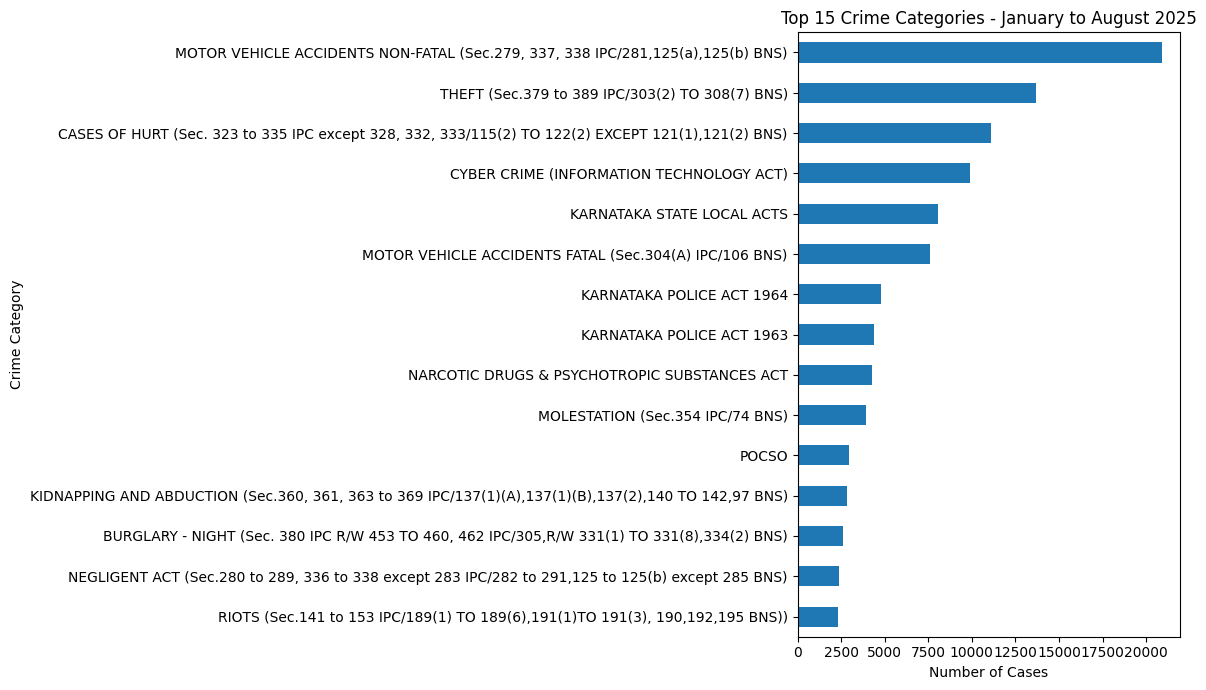

In [64]:
#top Crime Categories

top_crimes = (
    crime_df.groupby("Crime_Section")["Jan_Aug_2025"].sum().sort_values(ascending = False).head(15)
)
plt.figure(figsize = (12,7))

top_crimes.sort_values().plot(kind = "barh")

plt.title("Top 15 Crime Categories - January to August 2025")
plt.xlabel("Number of Cases")
plt.ylabel("Crime Category")

plt.tight_layout()
plt.show()

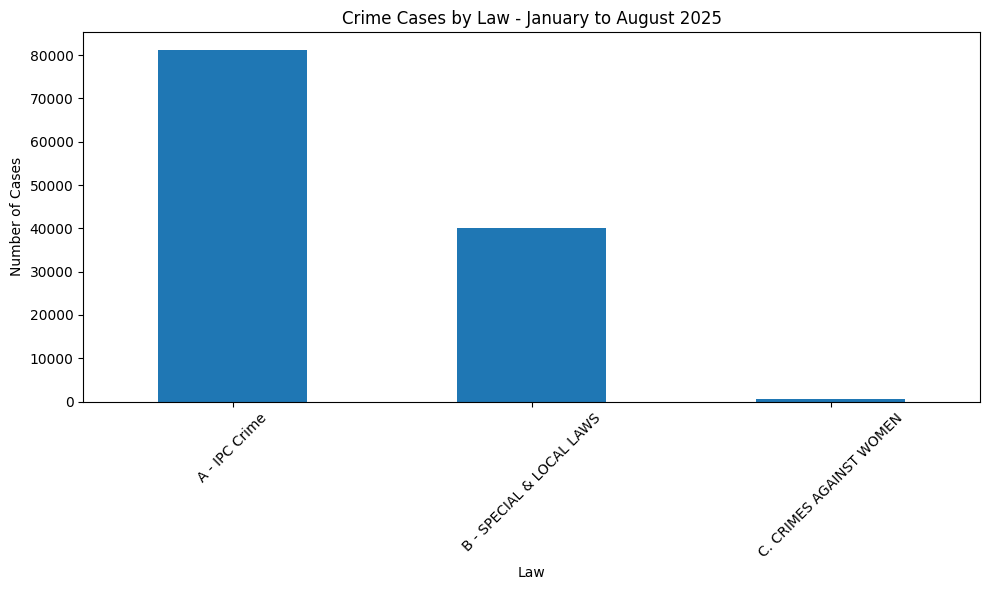

In [65]:
#Total cases by law

law_crimes = (
    crime_df.groupby('Law')['Jan_Aug_2025'].sum().sort_values(ascending = False)
)

plt.figure(figsize = (10, 6))
law_crimes.plot(kind = 'bar')

plt.title("Crime Cases by Law - January to August 2025")
plt.xlabel("Law")
plt.ylabel("Number of Cases")

plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

In [66]:
#Monthly Comparison

monthly_comparison = (crime_df.groupby("Crime_Section")[['July_2025', 'Aug_2025']].sum().sort_values("Aug_2025", ascending = False).head(15))

monthly_comparison

,July_2025,Aug_2025
Crime_Section,,
"MOTOR VEHICLE ACCIDENTS NON-FATAL (Sec.279, 337, 338 IPC/281,125(a),125(b) BNS)",2424.0,2571.0
THEFT (Sec.379 to 389 IPC/303(2) TO 308(7) BNS),1673.0,1569.0
CYBER CRIME (INFORMATION TECHNOLOGY ACT),1320.0,1264.0
"CASES OF HURT (Sec. 323 to 335 IPC except 328, 332, 333/115(2) TO 122(2) EXCEPT 121(1),121(2) BNS)",1353.0,1235.0
KARNATAKA STATE LOCAL ACTS,931.0,843.0
MOTOR VEHICLE ACCIDENTS FATAL (Sec.304(A) IPC/106 BNS),790.0,773.0
NARCOTIC DRUGS & PSYCHOTROPIC SUBSTANCES ACT,701.0,739.0
KARNATAKA POLICE ACT 1964,562.0,517.0
KARNATAKA POLICE ACT 1963,527.0,451.0


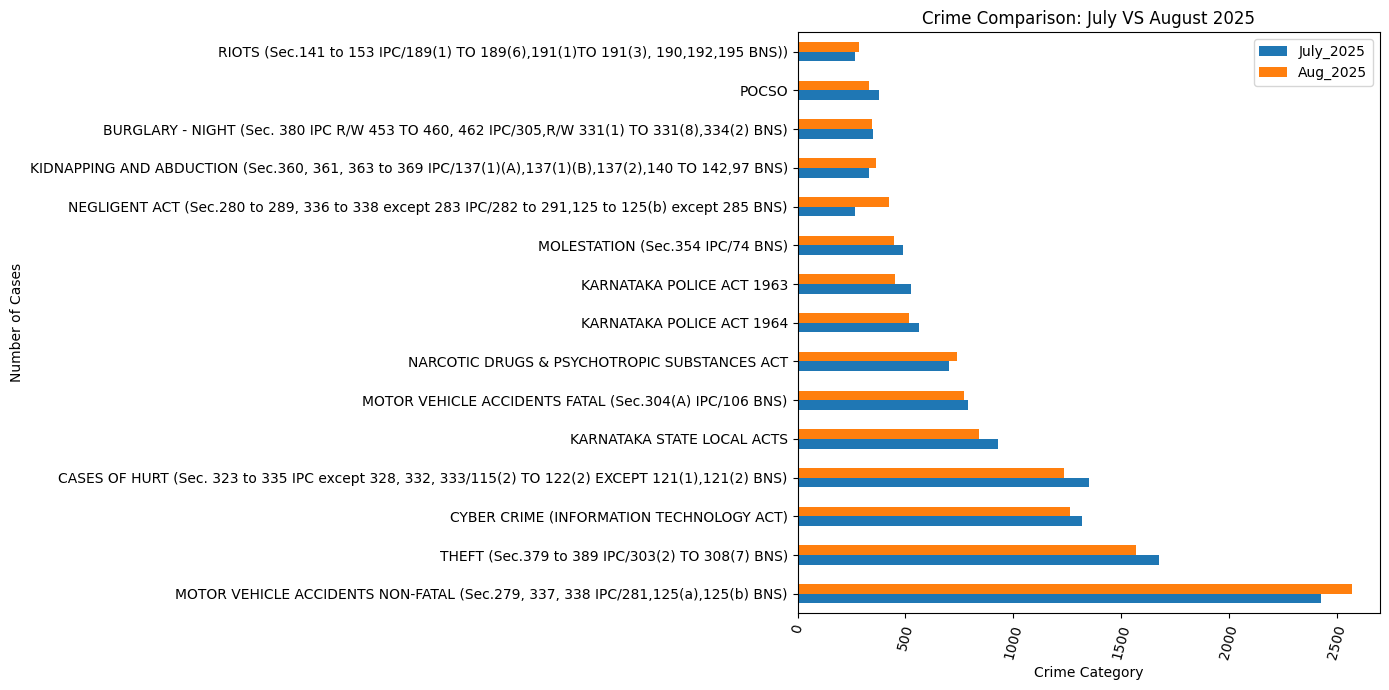

In [67]:
monthly_comparison.plot(
    kind = "barh",
    figsize = (14, 7)
)

plt.title("Crime Comparison: July VS August 2025")
plt.xlabel("Crime Category")
plt.ylabel("Number of Cases")

plt.xticks(rotation = 75)

plt.tight_layout()
plt.show()

In [68]:
#August2024 VS August2025

year_comparison = (
    crime_df.groupby("Crime_Section")[["Aug_2024", "Aug_2025"]].sum().sort_values("Aug_2025", ascending = False).head(15)
)
year_comparison

,Aug_2024,Aug_2025
Crime_Section,,
"MOTOR VEHICLE ACCIDENTS NON-FATAL (Sec.279, 337, 338 IPC/281,125(a),125(b) BNS)",2474.0,2571.0
THEFT (Sec.379 to 389 IPC/303(2) TO 308(7) BNS),1802.0,1569.0
CYBER CRIME (INFORMATION TECHNOLOGY ACT),1823.0,1264.0
"CASES OF HURT (Sec. 323 to 335 IPC except 328, 332, 333/115(2) TO 122(2) EXCEPT 121(1),121(2) BNS)",1260.0,1235.0
KARNATAKA STATE LOCAL ACTS,653.0,843.0
MOTOR VEHICLE ACCIDENTS FATAL (Sec.304(A) IPC/106 BNS),842.0,773.0
NARCOTIC DRUGS & PSYCHOTROPIC SUBSTANCES ACT,437.0,739.0
KARNATAKA POLICE ACT 1964,479.0,517.0
KARNATAKA POLICE ACT 1963,482.0,451.0


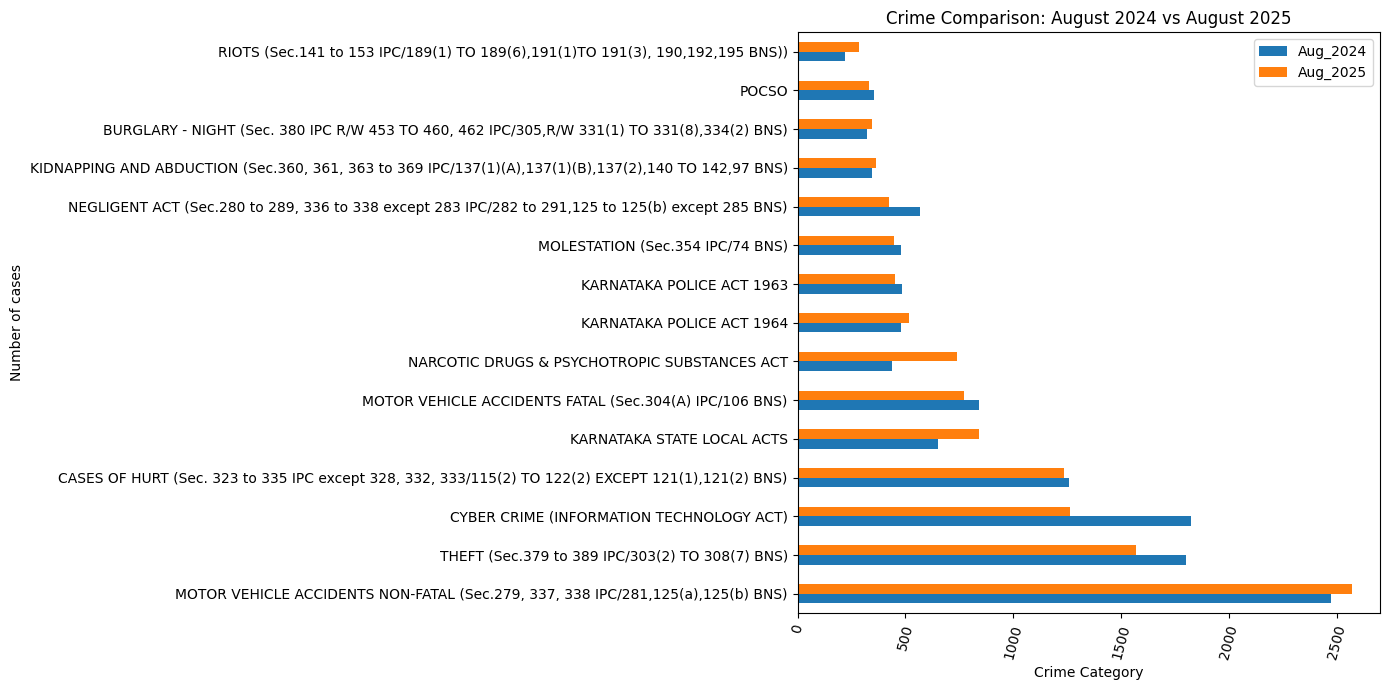

In [69]:
year_comparison.plot(
    kind = "barh",
    figsize = (14, 7)
)

plt.title("Crime Comparison: August 2024 vs August 2025")
plt.xlabel("Crime Category")
plt.ylabel("Number of cases")

plt.xticks(rotation = 75)

plt.tight_layout()
plt.show()


In [70]:
#Calculating the crime growth

crime_df["Change_July_to_August"] = (
    crime_df["Aug_2025"] - crime_df["July_2025"]
)

crime_df[
    ['Crime_Section',
     'July_2025',
     'Aug_2025',
     'Change_July_to_August']
].head()

,Crime_Section,July_2025,Aug_2025,Change_July_to_August
0,"Murder (Sec.302/303 IPC/103,104 BNS)",3.0,3.0,0.0
1,"Murder (Sec.302/303 IPC/103,104 BNS)",2.0,1.0,-1.0
2,"Murder (Sec.302/303 IPC/103,104 BNS)",3.0,3.0,0.0
3,"Murder (Sec.302/303 IPC/103,104 BNS)",1.0,2.0,1.0
4,"Murder (Sec.302/303 IPC/103,104 BNS)",0.0,0.0,0.0


In [71]:
#Calculate yearly change
crime_df["Change_Aug_2024_to_2025"] = (
    crime_df["Aug_2025"] - crime_df["Aug_2024"]
)

crime_df[
    ['Crime_Section',
     'Aug_2024',
     'Aug_2025',
     'Change_Aug_2024_to_2025'

    ]
].head()

,Crime_Section,Aug_2024,Aug_2025,Change_Aug_2024_to_2025
0,"Murder (Sec.302/303 IPC/103,104 BNS)",4.0,3.0,-1.0
1,"Murder (Sec.302/303 IPC/103,104 BNS)",1.0,1.0,0.0
2,"Murder (Sec.302/303 IPC/103,104 BNS)",2.0,3.0,1.0
3,"Murder (Sec.302/303 IPC/103,104 BNS)",1.0,2.0,1.0
4,"Murder (Sec.302/303 IPC/103,104 BNS)",0.0,0.0,0.0


In [72]:
#Percentage Change

crime_df['Percentage_Change'] = np.where(
    crime_df['Aug_2024'] != 0,
    (
        (crime_df['Aug_2025'] - crime_df['Aug_2024']) / crime_df['Aug_2024']
    )* 100,
    np.nan
)

crime_df[
    ['Crime_Section',
     'Aug_2024',
     'Aug_2025',
     'Percentage_Change']
].head(10)

,Crime_Section,Aug_2024,Aug_2025,Percentage_Change
0,"Murder (Sec.302/303 IPC/103,104 BNS)",4.0,3.0,-25.0
1,"Murder (Sec.302/303 IPC/103,104 BNS)",1.0,1.0,0.0
2,"Murder (Sec.302/303 IPC/103,104 BNS)",2.0,3.0,50.0
3,"Murder (Sec.302/303 IPC/103,104 BNS)",1.0,2.0,100.0
4,"Murder (Sec.302/303 IPC/103,104 BNS)",0.0,0.0,NaN
5,"Murder (Sec.302/303 IPC/103,104 BNS)",2.0,0.0,-100.0
6,"Murder (Sec.302/303 IPC/103,104 BNS)",0.0,0.0,NaN
7,"Murder (Sec.302/303 IPC/103,104 BNS)",0.0,0.0,NaN
8,"Murder (Sec.302/303 IPC/103,104 BNS)",0.0,0.0,NaN
9,"Murder (Sec.302/303 IPC/103,104 BNS)",0.0,0.0,NaN


In [73]:
#Highest increasing crimes

highest_increase = (
    crime_df[
        ['Crime_Section',
         'Aug_2024',
         'Aug_2025',
         'Percentage_Change']
    ].sort_values(
        'Percentage_Change',
        ascending = False
    ).head(15)
)

highest_increase

,Crime_Section,Aug_2024,Aug_2025,Percentage_Change
654,CYBER CRIME (INFORMATION TECHNOLOGY ACT),7.0,186.0,2557.142857
672,CYBER CRIME (INFORMATION TECHNOLOGY ACT),23.0,310.0,1247.826087
170,THEFT (Sec.379 to 389 IPC/303(2) TO 308(7) BNS),1.0,13.0,1200.000000
656,CYBER CRIME (INFORMATION TECHNOLOGY ACT),4.0,52.0,1200.000000
649,CYBER CRIME (INFORMATION TECHNOLOGY ACT),6.0,63.0,950.000000
566,FOREIGNER,1.0,10.0,900.000000
648,CYBER CRIME (INFORMATION TECHNOLOGY ACT),14.0,138.0,885.714286
662,CYBER CRIME (INFORMATION TECHNOLOGY ACT),5.0,49.0,880.000000
668,CYBER CRIME (INFORMATION TECHNOLOGY ACT),10.0,72.0,620.000000
101,Sexual Intercourse by employing deceitful mean...,3.0,21.0,600.000000


In [74]:
#Biggest Decrease

highest_decrease = (
    crime_df[
        ['Crime_Section',
         'Aug_2024',
         'Aug_2025',
         'Percentage_Change']
    ].sort_values(
        'Percentage_Change',
        ascending = True
    ).head(15)
)

highest_decrease

,Crime_Section,Aug_2024,Aug_2025,Percentage_Change
80,ATTEMPT TO CULPABLE HOMICIDE NOT AMOUNTING TO ...,2.0,0.0,-100.0
119,"KIDNAPPING AND ABDUCTION (Sec.360, 361, 363 to...",1.0,0.0,-100.0
637,KARNATAKA STATE LOCAL ACTS,2.0,0.0,-100.0
624,KARNATAKA STATE LOCAL ACTS,1.0,0.0,-100.0
578,PASSPORT ACT,1.0,0.0,-100.0
581,REPRESENTATIVE OF PEOPLE ACT 1951 & 1989,1.0,0.0,-100.0
603,KARNATAKA STATE LOCAL ACTS,1.0,0.0,-100.0
595,KARNATAKA STATE LOCAL ACTS,2.0,0.0,-100.0
311,CRIMINAL TRESPASS (Sec.447 to 452 IPC/329(3) T...,1.0,0.0,-100.0
318,CRIMINAL TRESPASS (Sec.447 to 452 IPC/329(3) T...,1.0,0.0,-100.0


In [75]:
#Creating Features and targets (X and y)

X = crime_df[
    [
        'Jan_Aug_2025',
        'Aug_2024',
        'July_2025'
    ]
]

y = crime_df['Aug_2025']

print("Features: ")
print(X.head())

print("\n Target: ")
print(y.head())

Features: 
   Jan_Aug_2025  Aug_2024  July_2025
0          24.0       4.0        3.0
1          17.0       1.0        2.0
2          26.0       2.0        3.0
3          16.0       1.0        1.0
4           1.0       0.0        0.0

 Target: 
0    3.0
1    1.0
2    3.0
3    2.0
4    0.0
Name: Aug_2025, dtype: float64


In [76]:
#Train and test and split the dataset

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 43)

print("Training rows: ", X_train.shape[0])
print("Testing rows: ", X_test.shape[0])

Training rows:  551
Testing rows:  138


In [77]:
# Linear Regression

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_prediction = linear_model.predict(X_test)

In [78]:
#Evaluating Linear Regression

linear_mae = mean_absolute_error(
    y_test,
    linear_prediction
)
linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_prediction
    )
)

linear_r2 = r2_score(
    y_test,
    linear_prediction
)

print("Linear Regression Results: ")
print("MAE: ", linear_mae)
print("RMSE: ", linear_rmse)
print("r2_score: ", linear_r2)

Linear Regression Results: 
MAE:  2.1500551535217065
RMSE:  6.1389344660290766
r2_score:  0.9846003032960036


In [79]:
#Using Randomforest regression

rf_model = RandomForestRegressor(
    n_estimators = 200,
    random_state = 42
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(X_test)


In [80]:
#evaluating randomforest regressor

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("RamdomForest Regression Results: ")

print("MAE: ", rf_mae)
print("RMSE: ", rf_rmse)
print("r2_score: ", rf_r2)

RamdomForest Regression Results: 
MAE:  1.8880739868273229
RMSE:  5.432519752745208
r2_score:  0.987940513901832


In [81]:
#Comparing both models

model_results = pd.DataFrame({
    "Model" : [
        'Linear Regression',
        "Random Forest"
    ],
    'MAE' : [
        linear_mae,
        rf_mae
    ],

    'RMSE' : [
        linear_rmse,
        rf_rmse
    ],

    'r2_score' : [
        linear_r2,
        rf_r2
    ]
})

model_results

,Model,MAE,RMSE,r2_score
0,Linear Regression,2.150055,6.138934,0.984600
1,Random Forest,1.888074,5.432520,0.987941


In [82]:
#Feature importance

feature_importance = pd.DataFrame({
    'Feature' : X.columns,
    'Importance' : rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending = False
)

feature_importance

,Feature,Importance
2,July_2025,0.619799
0,Jan_Aug_2025,0.305318
1,Aug_2024,0.074884


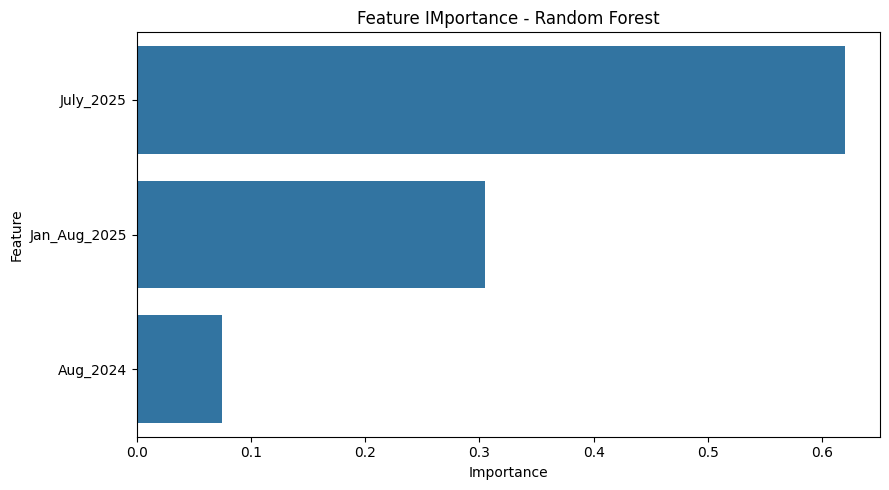

In [83]:
#Visualization

plt.figure(figsize = (9, 5))

sns.barplot(
    data =feature_importance,
    x = "Importance",
    y = "Feature"
)

plt.title("Feature IMportance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [84]:
#Actual VS Predicted

Predicted_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted" : rf_predictions
})

Predicted_comparison.head(20)

,Actual,Predicted
0,8.0,3.445500
1,202.0,196.635000
2,25.0,41.355000
3,24.0,18.500000
4,0.0,0.000000
5,1.0,0.446818
6,0.0,0.000000
7,0.0,0.000000
8,10.0,6.544000
9,0.0,0.000000


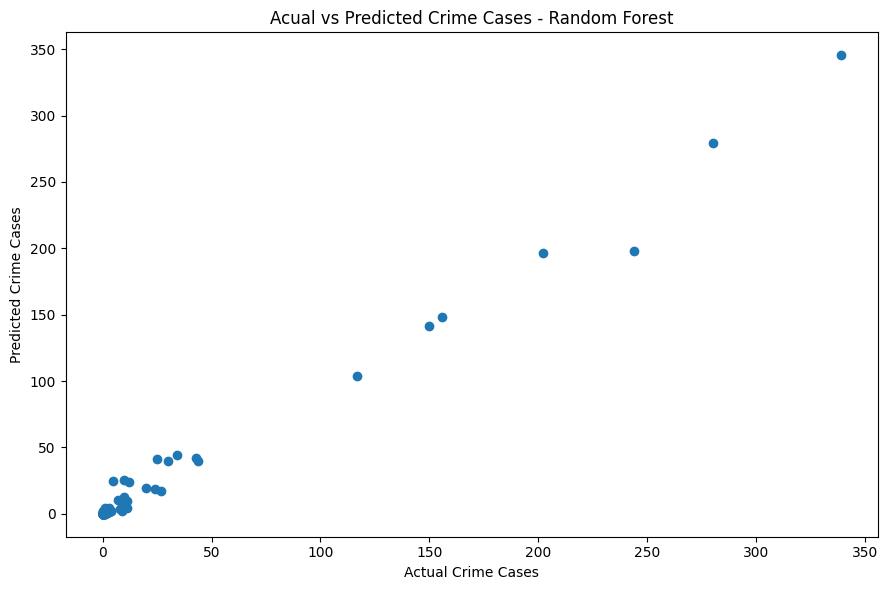

In [85]:
plt.figure(figsize = (9, 6))
plt.scatter(
    y_test,
    rf_predictions
)

plt.xlabel("Actual Crime Cases")
plt.ylabel("Predicted Crime Cases")

plt.title(
    "Acual vs Predicted Crime Cases - Random Forest"
)

plt.tight_layout()
plt.show()